<a href="https://colab.research.google.com/github/Prajwal-Luitel/Twitter-Sentiment-Analysis/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
!pip install kagglehub[pandas-datasets]

# Importing the Dataset
### Link: https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis/data

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
train_path = "twitter_training.csv"
vald_path = "twitter_validation.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jp797498e/twitter-entity-sentiment-analysis",
  train_path,
  pandas_kwargs={"header": None}, # Add "compression": "zip" when running locally
)

print("First 5 records:", df.head())

First 5 records:       0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [5]:
df.columns=['id','information','label','tweet']
df.head()

,id,information,label,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# EDA

## Number of Null Values in each column

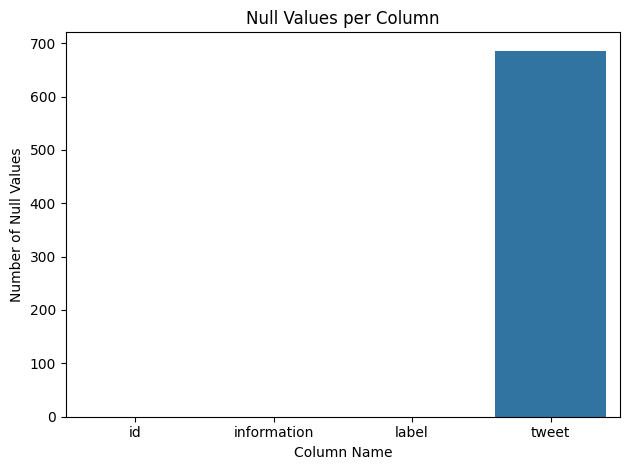

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count nulls per column
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ['column', 'null_count']
# Plot null counts
sns.barplot(
    data=null_counts,
    x='column',
    y='null_count',
)
plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.title('Null Values per Column')
plt.tight_layout()
plt.show()

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           74682 non-null  int64 
 1   information  74682 non-null  object
 2   label        74682 non-null  object
 3   tweet        73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


### Removing Null Values

In [6]:
df.dropna(inplace=True)

## Number of each sentiment class

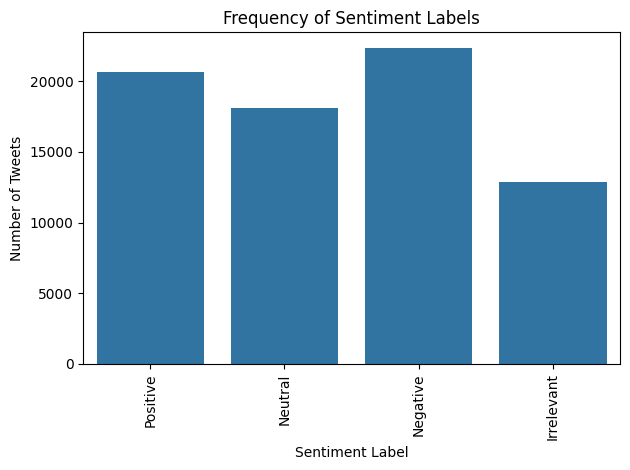

In [84]:
sns.countplot(data=df, x="label")
plt.xticks(rotation=90)
plt.title("Frequency of Sentiment Labels")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()


## Distribution of tweets per Branch and Label

In [85]:
plot=df.groupby(by=["information","label"]).count().reset_index()
plot.head()

,information,label,id,tweet
0,Amazon,Irrelevant,186,186
1,Amazon,Negative,575,575
2,Amazon,Neutral,1207,1207
3,Amazon,Positive,308,308
4,ApexLegends,Irrelevant,192,192


Text(0.5, 1.0, 'Distribution of tweets per Branch and Label')

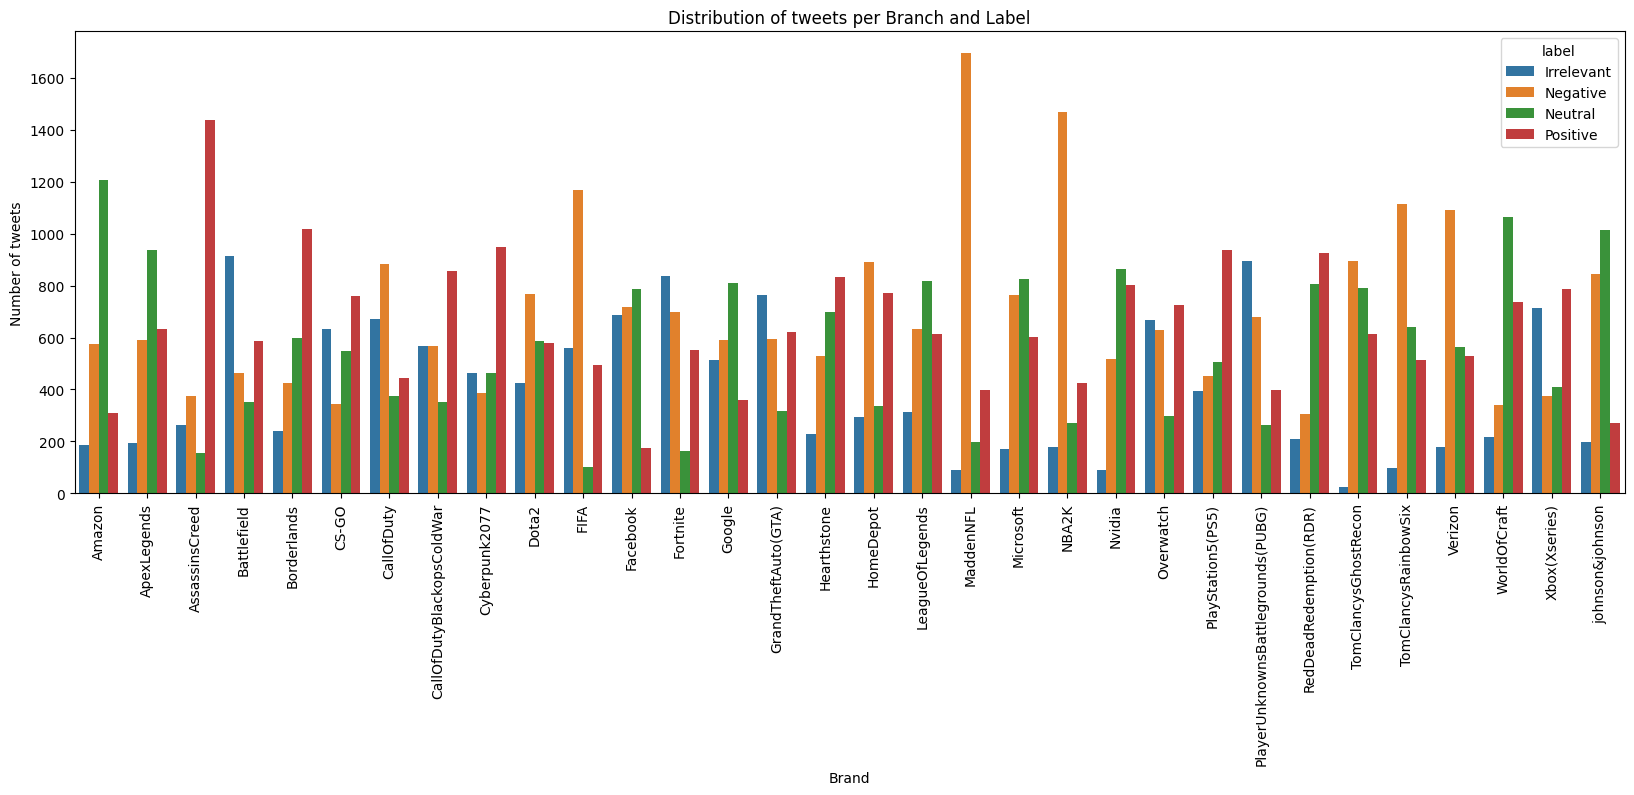

In [ ]:
#Figure of comparison per label
plt.figure(figsize=(20,6))
sns.barplot(data=plot,x="information",y="id",hue="label")
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Number of tweets")
plt.title("Distribution of tweets per Branch and Label")
plt.tight_layout()
plt.show()

# Text Preprocessing

In [7]:
import nltk
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize the lemmatizer
wnl = WordNetLemmatizer()

def preprocessing(raw_text):
  stop_words = set(stopwords.words("english"))

  raw_text = str(raw_text)
  # Use word_tokenize for better tokenization before lemmatization
  words = word_tokenize(raw_text.lower())

  filtered_words = [word for word in words if word not in stop_words and word not in string.punctuation]
  lemmas = [wnl.lemmatize(word,pos="v") for word in filtered_words]
  return " ".join(lemmas)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
df['Preprocessed_Text'] = df['tweet'].apply(preprocessing)

In [89]:
df.sample(7)

,id,information,label,tweet,Preprocessed_Text
16495,9625,PlayStation5(PS5),Irrelevant,I scream.,scream
14781,2932,Dota2,Irrelevant,Just Surfer and its subscribers away from the ...,surfer subscribers away hot good time sit orig...
52660,10646,RedDeadRedemption(RDR),Neutral,with Red Dead Redemption pic.twitter.com/qNN6C...,red dead redemption pic.twitter.com/qnn6cnz5yq
56038,11218,TomClancysRainbowSix,Positive,Maybe I love this,maybe love
64212,7802,MaddenNFL,Negative,Fire all the creators and editors of @EAMadden...,fire creators editors eamaddennfl 0 effort imp...
31812,7461,LeagueOfLegends,Positive,something about lulu from league of legends th...,something lulu league legends make emotional ....
42193,10039,PlayerUnknownsBattlegrounds(PUBG),Negative,Breaking: PUBG BANNED OF GOVT OF INDIA,break pubg ban govt india


# Word Clouds

In [2]:
!pip install wordcloud

In [9]:
tweet = df["Preprocessed_Text"]
all_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Positive"]["Preprocessed_Text"]
positive_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Negative"]["Preprocessed_Text"]
negative_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Neutral"]["Preprocessed_Text"]
neutral_text = tweet.str.cat(sep=" ")

tweet = df[df["label"]=="Irrelevant"]["Preprocessed_Text"]
irrelevant_text = tweet.str.cat(sep=" ")

In [10]:
from wordcloud import WordCloud #Word visualization

In [13]:
def generate_word_cloud(text,title="Tweets"):
  #Creation of wordcloud
  wordcloud = WordCloud(
    width=1500,
    height=1000,
    max_words=150,
    random_state=42,
    collocations=False,
    background_color="white"
  ).generate(text)

  #Figure properties
  plt.figure(figsize=(14,8))
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Word Cloud For: {title}", fontsize=40)
  plt.tight_layout()
  plt.show()




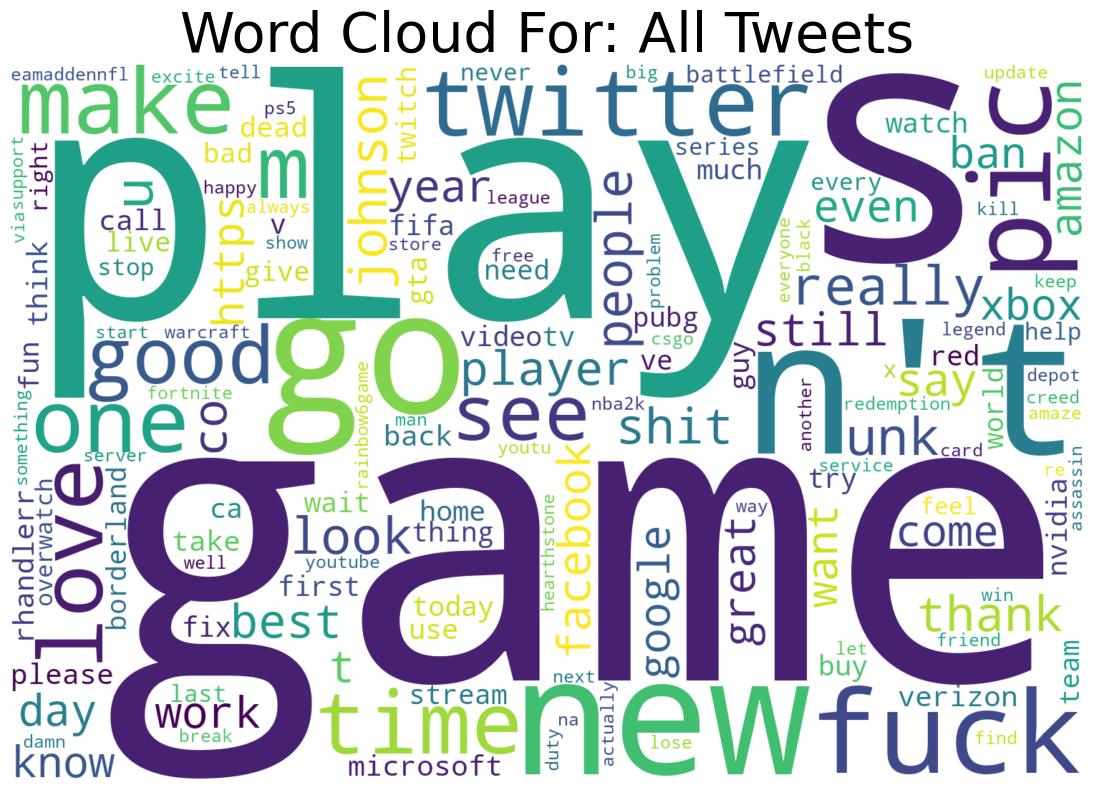

In [14]:
generate_word_cloud(all_text,"All Tweets")

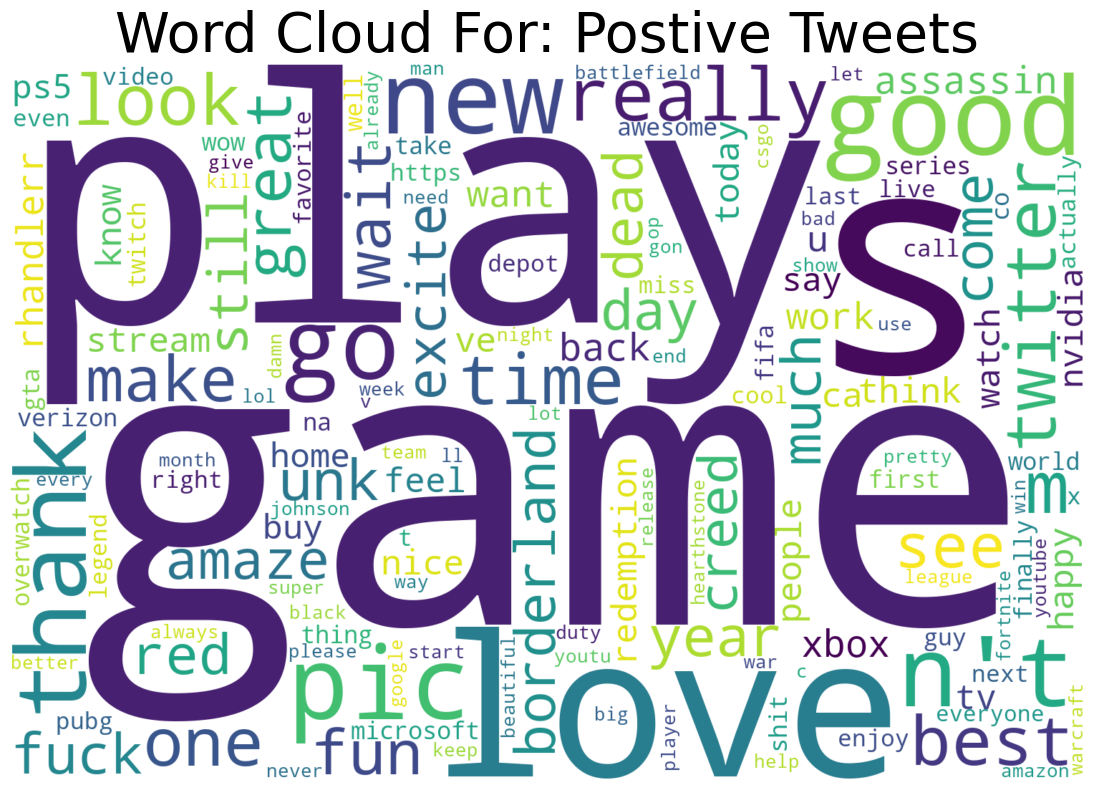

In [15]:
generate_word_cloud(positive_text,"Postive Tweets")

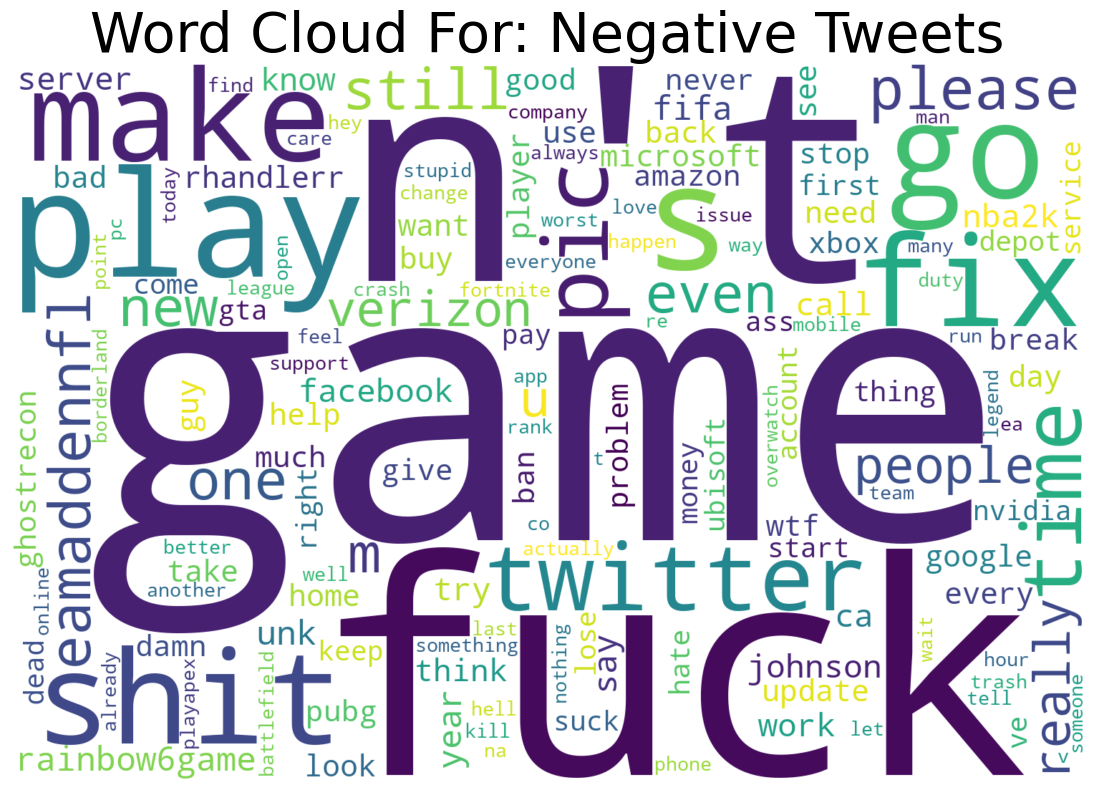

In [16]:
generate_word_cloud(negative_text,"Negative Tweets")

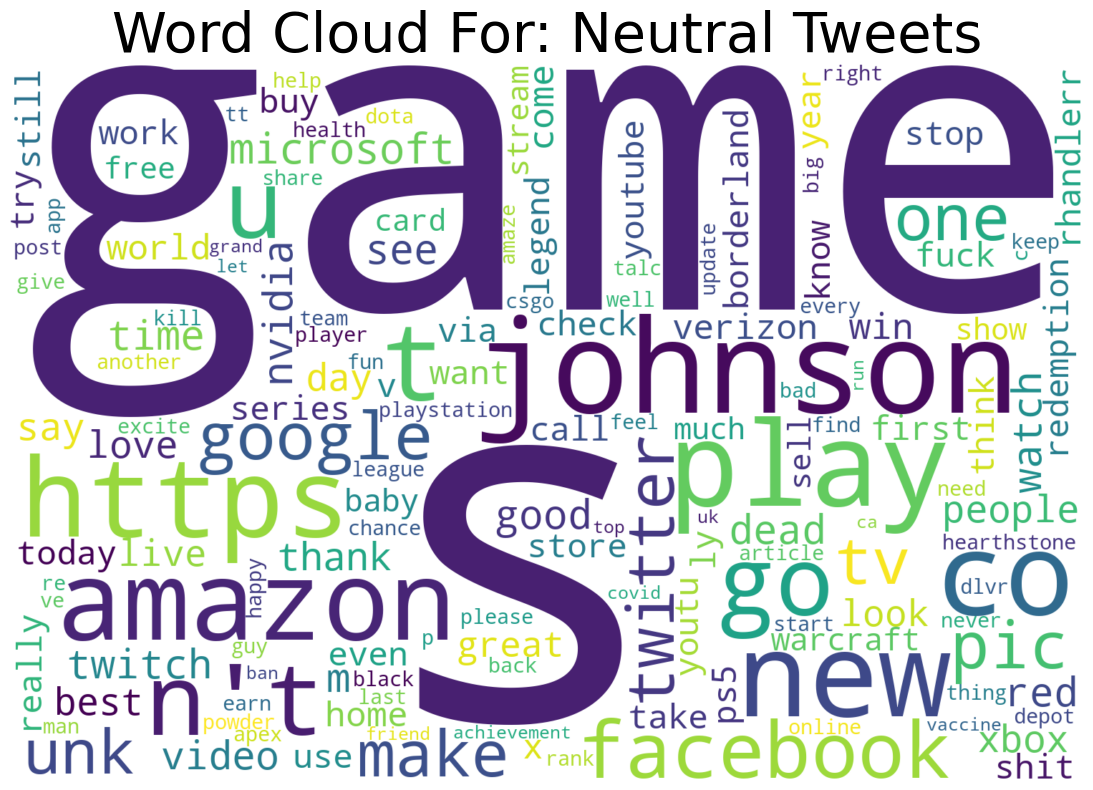

In [17]:
generate_word_cloud(neutral_text,"Neutral Tweets")

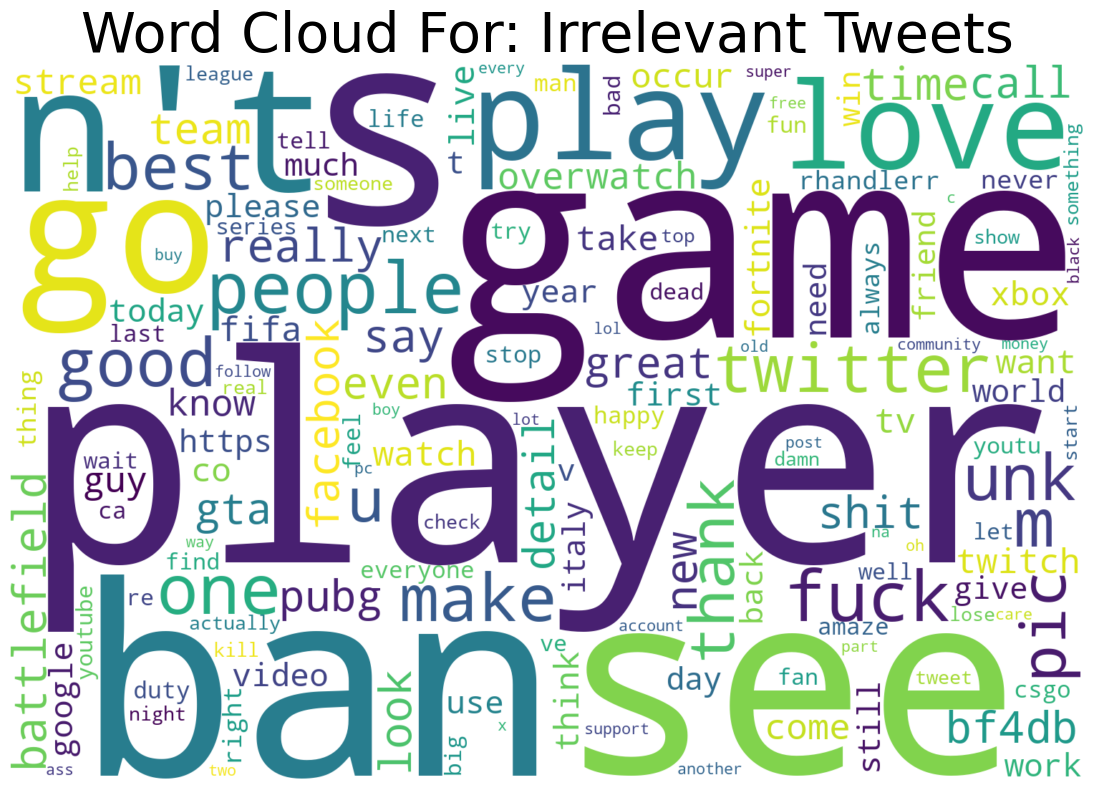

In [18]:
generate_word_cloud(irrelevant_text,"Irrelevant Tweets")

# Preprocessing

## Label Encoding

In [98]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [99]:
df

,id,information,label,tweet,Preprocessed_Text
0,2401,Borderlands,3,im getting on borderlands and i will murder yo...,im get borderlands murder
1,2401,Borderlands,3,I am coming to the borders and I will kill you...,come border kill
2,2401,Borderlands,3,im getting on borderlands and i will kill you ...,im get borderlands kill
3,2401,Borderlands,3,im coming on borderlands and i will murder you...,im come borderlands murder
4,2401,Borderlands,3,im getting on borderlands 2 and i will murder ...,im get borderlands 2 murder
...,...,...,...,...,...
74677,9200,Nvidia,3,Just realized that the Windows partition of my...,realize windows partition mac like 6 years beh...
74678,9200,Nvidia,3,Just realized that my Mac window partition is ...,realize mac window partition 6 years behind nv...
74679,9200,Nvidia,3,Just realized the windows partition of my Mac ...,realize windows partition mac 6 years behind n...
74680,9200,Nvidia,3,Just realized between the windows partition of...,realize windows partition mac like 6 years beh...


## Train Test Split

In [100]:
from sklearn.model_selection import train_test_split
X = df[['Preprocessed_Text']]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [101]:
X_train.shape,X_test.shape

((55497, 1), (18499, 1))

In [102]:
y_train.shape,y_test.shape

((55497,), (18499,))

# Feature Engineering

In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

## Count Vectorizer

In [104]:
# Unigram
cv = ColumnTransformer(
    [("cv", CountVectorizer(), 'Preprocessed_Text')]
)

# Bigram
cv_bigram = ColumnTransformer(
    [("cv_bigram", CountVectorizer(ngram_range=(2, 2)), 'Preprocessed_Text')]
)

## TF-IDF Vectorizer

In [105]:
# Unigram
tfidf = ColumnTransformer(
    [("tfidf", TfidfVectorizer(), 'Preprocessed_Text')]
)

# Bigram
tfidf_bigram = ColumnTransformer(
    [("tfidf_bigram", TfidfVectorizer(ngram_range=(2, 2)), 'Preprocessed_Text')]
)

## Word to Vector

In [106]:
!pip install gensim

In [107]:
X_train_tokens = X_train['Preprocessed_Text'].apply(lambda x: x.split()).tolist()
X_test_tokens  = X_test['Preprocessed_Text'].apply(lambda x: x.split()).tolist()

In [108]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=5,
)

In [109]:
def sentence_to_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

In [110]:
X_train_w2v  = np.array([sentence_to_vector(tokens) for tokens in X_train_tokens])
X_test_w2v   = np.array([sentence_to_vector(tokens) for tokens in X_test_tokens])

# Training Model

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

## Random Forest

### Word2Vec

In [112]:
random_forest_wv = RandomForestClassifier(random_state=42, n_jobs=-1)

### Creating the Pipeline

#### Count Vector Pipeline

In [113]:
random_forest_cv = Pipeline([
    ('cv', cv),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_forest_cv_bigram = Pipeline([
    ('cv_bigram', cv_bigram),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

#### TF-IDF Pipeline

In [114]:
random_forest_tfidf = Pipeline([
    ('tfidf', tfidf),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

random_forest_tfidf_bigram = Pipeline([
    ('tfidf_bigram', tfidf_bigram),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

### Fitting the model

In [115]:
random_forest_wv.fit(X_train_w2v, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [116]:
random_forest_cv.fit(X_train, y_train)
random_forest_cv_bigram.fit(X_train, y_train)

Pipeline(steps=[('cv_bigram',
                 ColumnTransformer(transformers=[('cv_bigram',
                                                  CountVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('random_forest',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [117]:
random_forest_tfidf.fit(X_train, y_train)
random_forest_tfidf_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf_bigram',
                 ColumnTransformer(transformers=[('tfidf_bigram',
                                                  TfidfVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('random_forest',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

## Naive Bayes

In [118]:
multinomialNB_wv = MultinomialNB()

#### Count Vector Pipeline

In [119]:
multinomialNB_cv = Pipeline([
    ('cv', cv),
    ('multinomialNB', MultinomialNB())
])

multinomialNB_cv_bigram = Pipeline([
    ('cv_bigram', cv_bigram),
    ('multinomialNB', MultinomialNB()),
])

#### TF-IDF Pipeline

In [120]:
multinomialNB_tfidf = Pipeline([
    ('tfidf', tfidf),
    ('multinomialNB', MultinomialNB()),
])

multinomialNB_tfidf_bigram = Pipeline([
    ('tfidf_bigram', tfidf_bigram),
    ('multinomialNB', MultinomialNB()),
])

### Fitting the model

#### Note: MultiNomial NaiveBayes doesn't support negative number so can't be used for word2vec

In [121]:
multinomialNB_cv.fit(X_train, y_train)
multinomialNB_cv_bigram.fit(X_train, y_train)

Pipeline(steps=[('cv_bigram',
                 ColumnTransformer(transformers=[('cv_bigram',
                                                  CountVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('multinomialNB', MultinomialNB())])

In [122]:
multinomialNB_tfidf.fit(X_train, y_train)
multinomialNB_tfidf_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf_bigram',
                 ColumnTransformer(transformers=[('tfidf_bigram',
                                                  TfidfVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('multinomialNB', MultinomialNB())])

# Model Evalutation

### Function for diagram

In [156]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score,\
                            confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
                            
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

result_df = pd.DataFrame(
    columns=["model name", "accuracy", "precision", "recall", "f1"]
)

def save_result(y_pred, title):
    accuracy = np.round(accuracy_score(y_test, y_pred), 2)
    precision = np.round(precision_score(y_test, y_pred, average="weighted"), 2)
    recall = np.round(recall_score(y_test, y_pred, average="weighted"), 2)
    f1 = np.round(f1_score(y_test, y_pred, average="weighted"), 2)

    result_df.loc[len(result_df)] = [title, accuracy, precision, recall, f1]

# Confusion Matrix
def display_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix for {title}")
    plt.tight_layout()
    plt.show()

# ROC Curve
def display_ROC(y_test, y_prob, classes_, title):
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=classes_)
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve for {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Function for displaying some predictions

In [157]:
def display_prediction(model,title= "Model"):
    sentence1 = "This new feature is a game changer, I love using this new feature"
    sentence2 = "This update is awful and ruined my workflow completely"
    
    data1 = pd.DataFrame({'Preprocessed_Text': [sentence1]})
    data2 = pd.DataFrame({'Preprocessed_Text': [sentence2]})
    
    # Predictions
    pred1 = model.predict(data1)
    pred2 = model.predict(data2)
    # Decode numeric labels to text
    decoded1 = le.inverse_transform(pred1)
    decoded2 = le.inverse_transform(pred2)
    print(f"Sentence is:\n{sentence1}\nPrediction by {title} is {decoded1[0]}")
    print(f"Sentence is:\n{sentence2}\nPrediction by {title} is {decoded2[0]}")

In [158]:
from sklearn.metrics import classification_report

def generate_evaluation(model, X_test, is_prediction = True, title=""):
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)
  
  print(f"{title} Evaluation:\n")
  print(f"Classification Report:")
  print(classification_report(y_test, y_pred))
  print("\n")
  save_result(y_pred, title)
  display_confusion_matrix(y_test, y_pred, title=title)
  display_ROC(y_test, y_prob, model.classes_, title=title)
  if is_prediction:
    display_prediction(model,title)

## Word2Vec Random Forest

Random Forest Word2Vec Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.55      0.65      3219
           1       0.74      0.82      0.78      5589
           2       0.73      0.69      0.71      4527
           3       0.69      0.79      0.74      5164

    accuracy                           0.73     18499
   macro avg       0.74      0.71      0.72     18499
weighted avg       0.74      0.73      0.73     18499





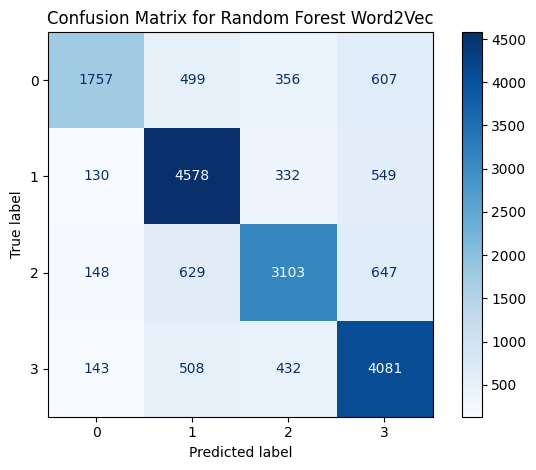

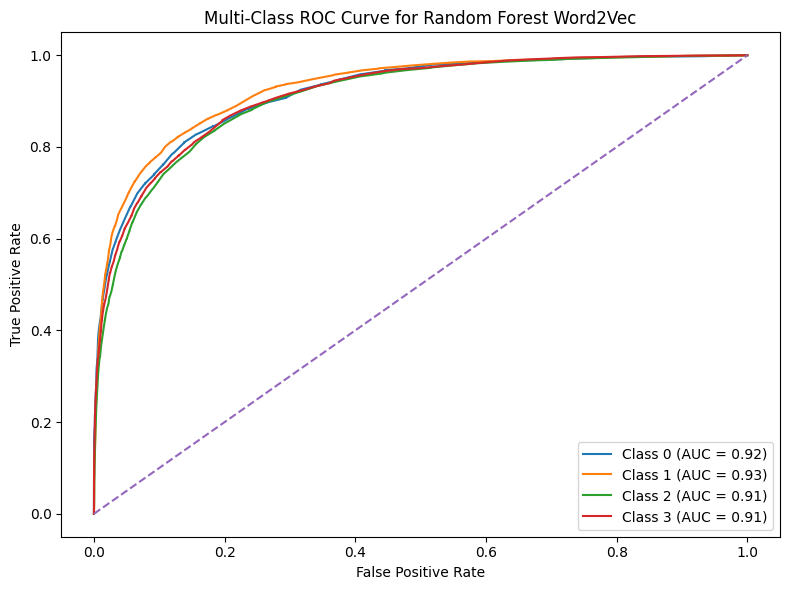

In [159]:
generate_evaluation(model=random_forest_wv, X_test=X_test_w2v, is_prediction=False, title="Random Forest Word2Vec")

In [160]:
sentence1 = "This new feature is a game changer, I love using this new feature"
sentence2 = "This update is awful and ruined my workflow completely"

sentence1_vec = sentence_to_vector(sentence1.split())
sentence2_vec = sentence_to_vector(sentence2.split())
# Predictions
pred1 = random_forest_wv.predict([sentence1_vec])
pred2 = random_forest_wv.predict([sentence2_vec])
# Decode numeric labels to text
decoded1 = le.inverse_transform(pred1)
decoded2 = le.inverse_transform(pred2)
print(f"Sentence is:\n{sentence1}\nPrediction by Random Forest Word2Vec is {decoded1[0]}\n")
print(f"Sentence is:\n{sentence2}\nPrediction by Random Forest Word2Vec is {decoded2[0]}\n")

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest Word2Vec is Positive

Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest Word2Vec is Negative



## Count Random Forest

Random Forest Count Vectorizer (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      3219
           1       0.92      0.93      0.93      5589
           2       0.88      0.92      0.90      4527
           3       0.90      0.92      0.91      5164

    accuracy                           0.91     18499
   macro avg       0.92      0.91      0.91     18499
weighted avg       0.91      0.91      0.91     18499





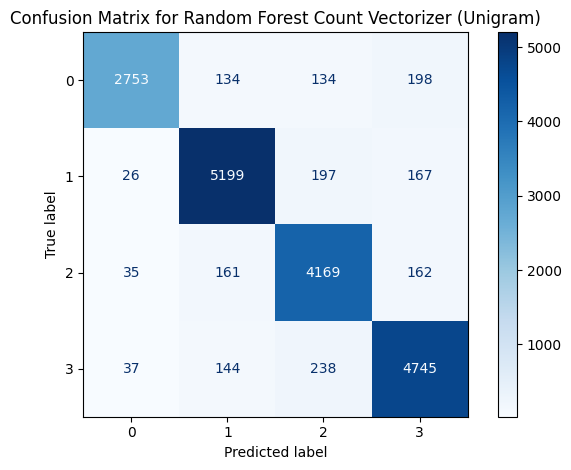

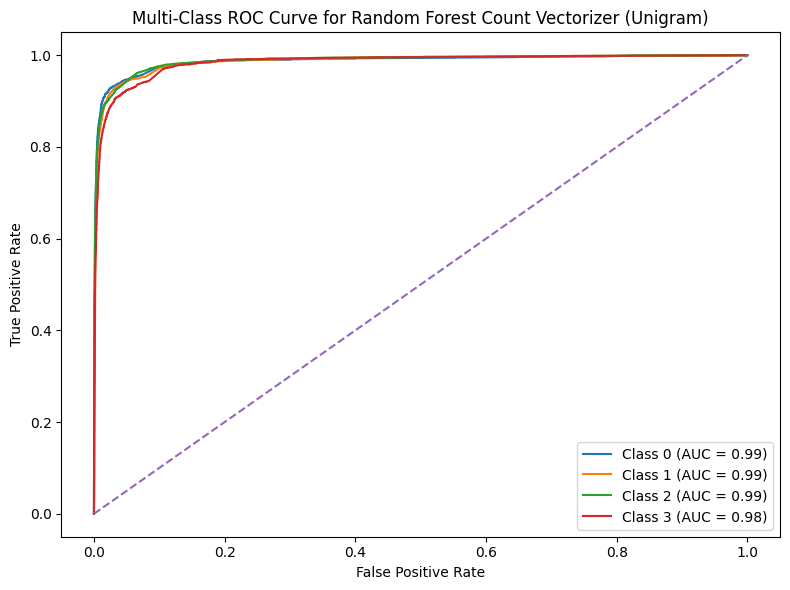

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest Count Vectorizer (Unigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest Count Vectorizer (Unigram) is Negative


In [161]:
generate_evaluation(model=random_forest_cv, X_test=X_test, title="Random Forest Count Vectorizer (Unigram)")

Random Forest Count Vectorizer (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      3219
           1       0.90      0.83      0.86      5589
           2       0.90      0.83      0.86      4527
           3       0.72      0.92      0.81      5164

    accuracy                           0.84     18499
   macro avg       0.87      0.83      0.84     18499
weighted avg       0.86      0.84      0.85     18499





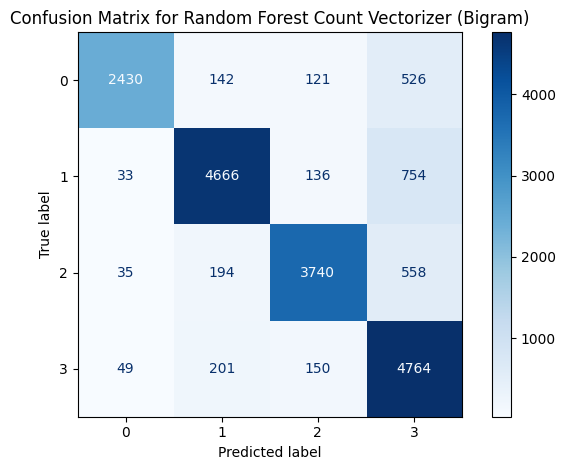

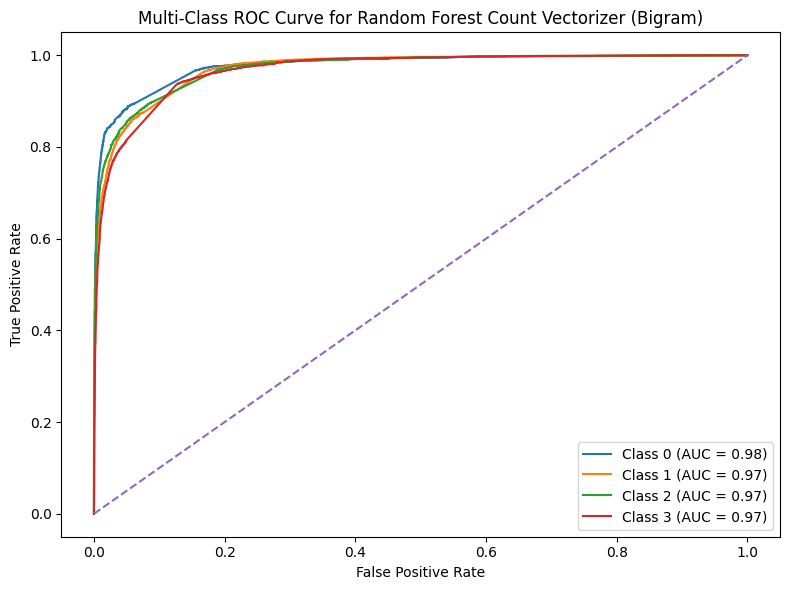

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest Count Vectorizer (Bigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest Count Vectorizer (Bigram) is Positive


In [162]:
generate_evaluation(model=random_forest_cv_bigram, X_test=X_test, title="Random Forest Count Vectorizer (Bigram)")

## TF-IDF Random Forest

Random Forest TF-IDF (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      3219
           1       0.92      0.93      0.93      5589
           2       0.88      0.92      0.90      4527
           3       0.90      0.92      0.91      5164

    accuracy                           0.91     18499
   macro avg       0.92      0.91      0.91     18499
weighted avg       0.92      0.91      0.91     18499





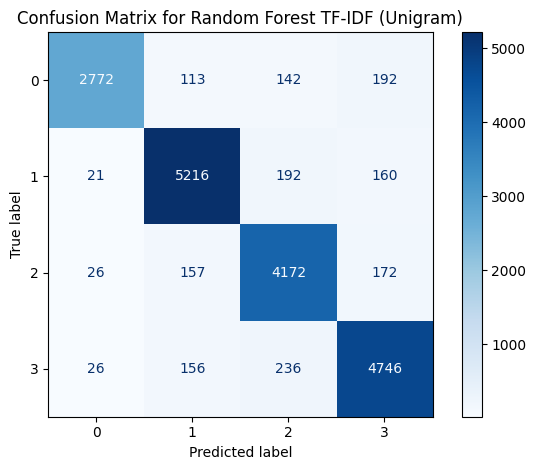

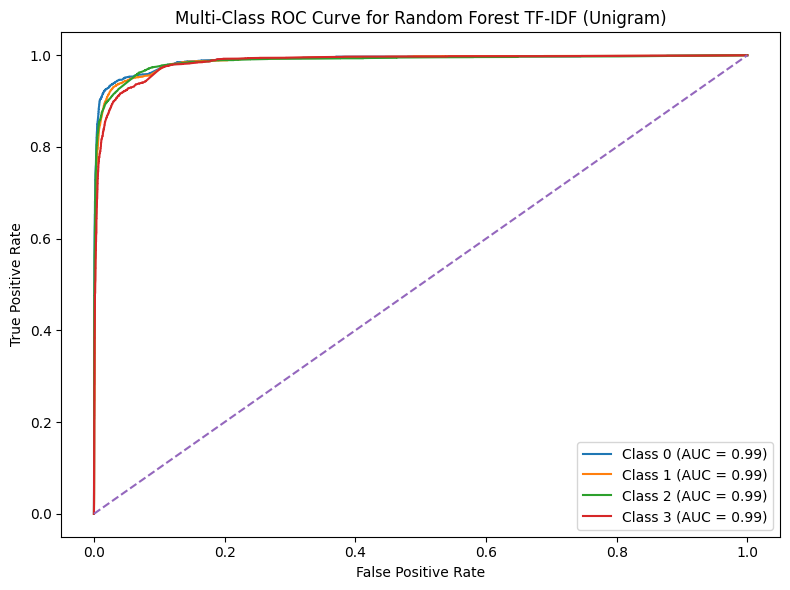

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest TF-IDF (Unigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest TF-IDF (Unigram) is Negative


In [163]:
generate_evaluation(model=random_forest_tfidf, X_test=X_test, title="Random Forest TF-IDF (Unigram)")

Random Forest TF-IDF (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      3219
           1       0.90      0.83      0.86      5589
           2       0.90      0.83      0.86      4527
           3       0.72      0.93      0.81      5164

    accuracy                           0.84     18499
   macro avg       0.87      0.83      0.84     18499
weighted avg       0.86      0.84      0.84     18499





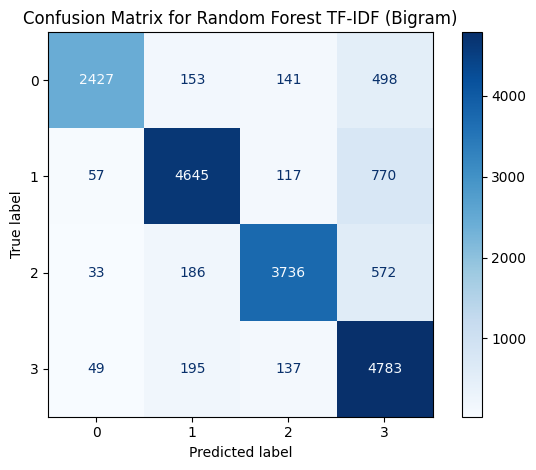

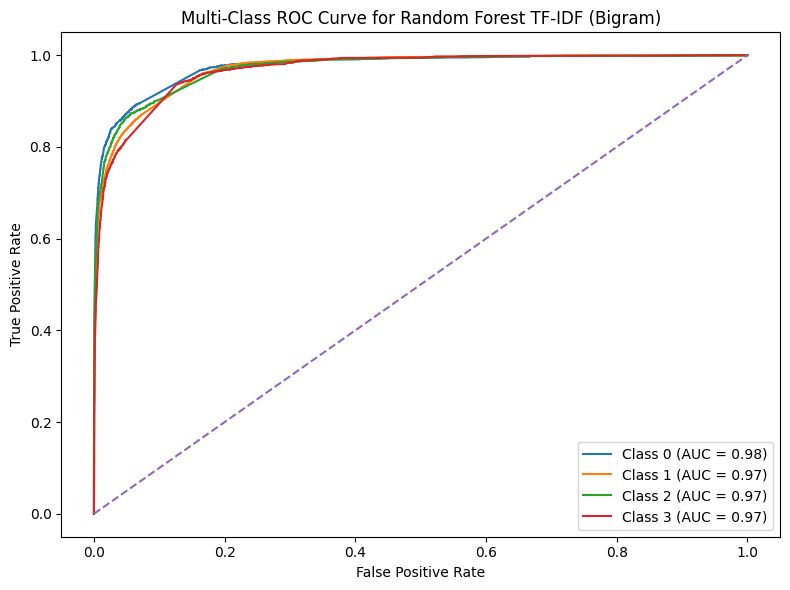

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Random Forest TF-IDF (Bigram) is Irrelevant
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Random Forest TF-IDF (Bigram) is Positive


In [164]:
generate_evaluation(model=random_forest_tfidf_bigram, X_test=X_test, title="Random Forest TF-IDF (Bigram)")

## Count Vectorizer MultiNomial NaiveBayes

Naive Bayes Count Vectorizer (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.62      0.71      3219
           1       0.69      0.85      0.76      5589
           2       0.81      0.64      0.71      4527
           3       0.72      0.79      0.76      5164

    accuracy                           0.74     18499
   macro avg       0.76      0.73      0.74     18499
weighted avg       0.75      0.74      0.74     18499





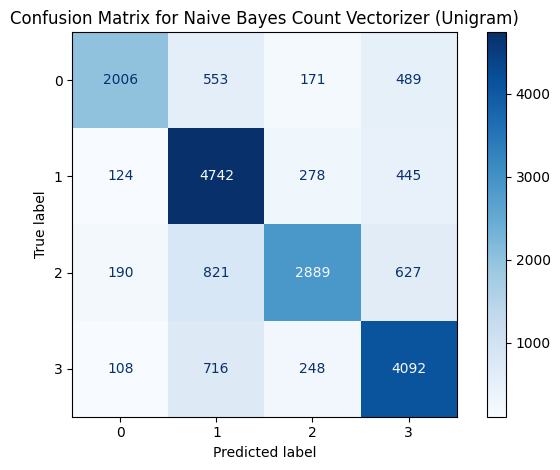

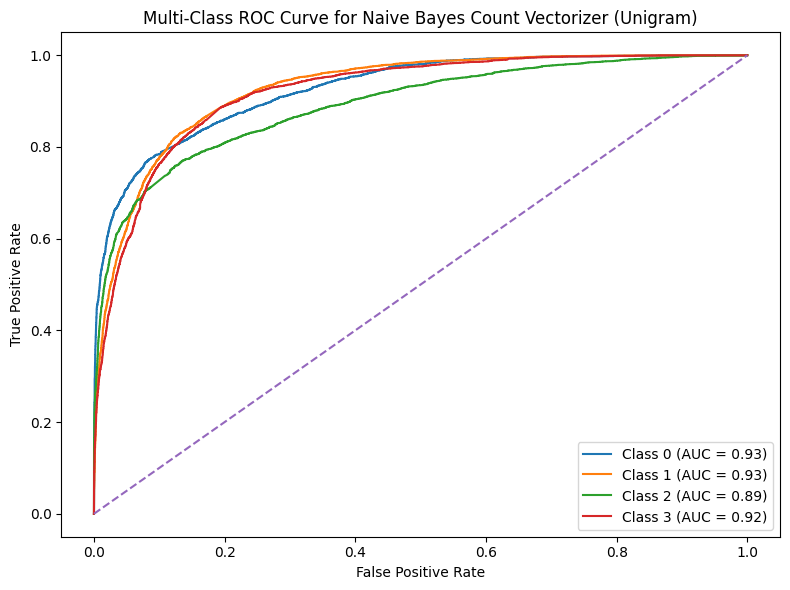

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes Count Vectorizer (Unigram) is Neutral
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes Count Vectorizer (Unigram) is Negative


In [165]:
generate_evaluation(model=multinomialNB_cv, X_test=X_test, title="Naive Bayes Count Vectorizer (Unigram)")

Naive Bayes Count Vectorizer (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      3219
           1       0.81      0.96      0.88      5589
           2       0.95      0.89      0.92      4527
           3       0.92      0.86      0.89      5164

    accuracy                           0.89     18499
   macro avg       0.91      0.89      0.90     18499
weighted avg       0.90      0.89      0.90     18499





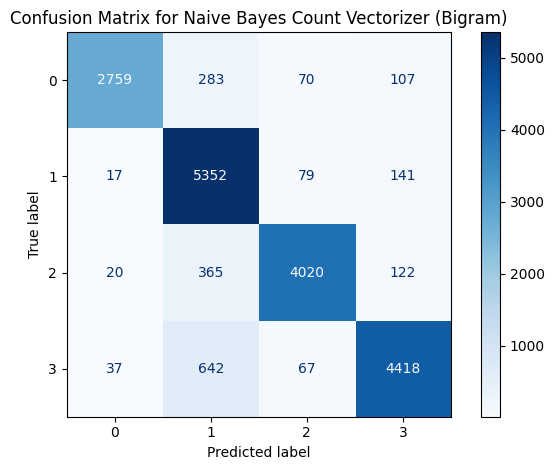

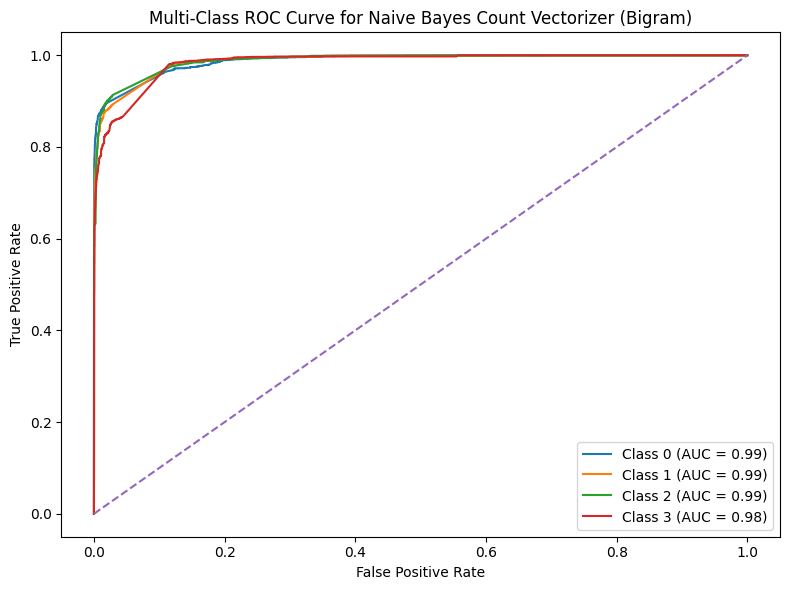

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes Count Vectorizer (Bigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes Count Vectorizer (Bigram) is Negative


In [166]:
generate_evaluation(model=multinomialNB_cv_bigram, X_test=X_test, title="Naive Bayes Count Vectorizer (Bigram)")

## TF-IDF MultiNomial NaiveBayes

Naive Bayes TF-IDF (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.43      0.59      3219
           1       0.65      0.90      0.75      5589
           2       0.83      0.62      0.71      4527
           3       0.70      0.81      0.75      5164

    accuracy                           0.72     18499
   macro avg       0.78      0.69      0.70     18499
weighted avg       0.76      0.72      0.71     18499





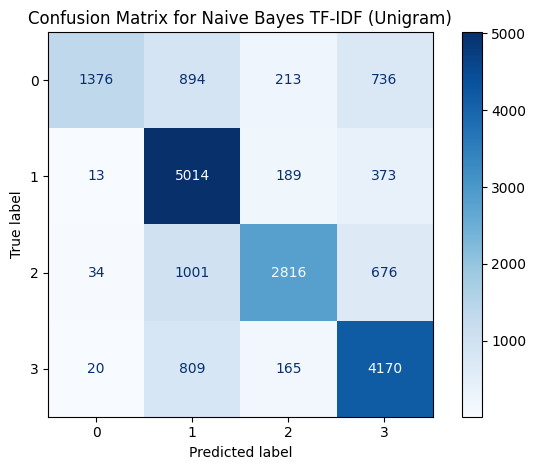

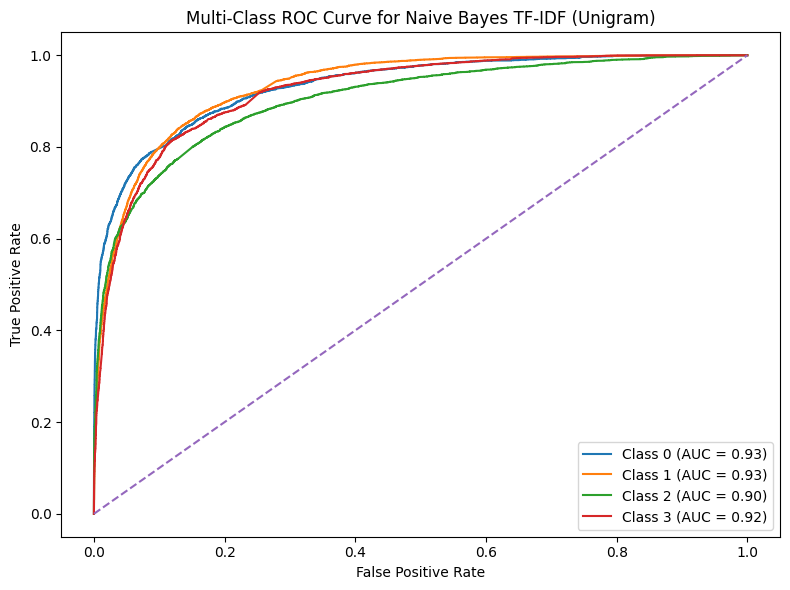

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes TF-IDF (Unigram) is Neutral
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes TF-IDF (Unigram) is Negative


In [167]:
generate_evaluation(model=multinomialNB_tfidf, X_test=X_test, title="Naive Bayes TF-IDF (Unigram)")

Naive Bayes TF-IDF (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      3219
           1       0.79      0.97      0.87      5589
           2       0.95      0.87      0.91      4527
           3       0.91      0.86      0.88      5164

    accuracy                           0.88     18499
   macro avg       0.91      0.87      0.89     18499
weighted avg       0.90      0.88      0.88     18499





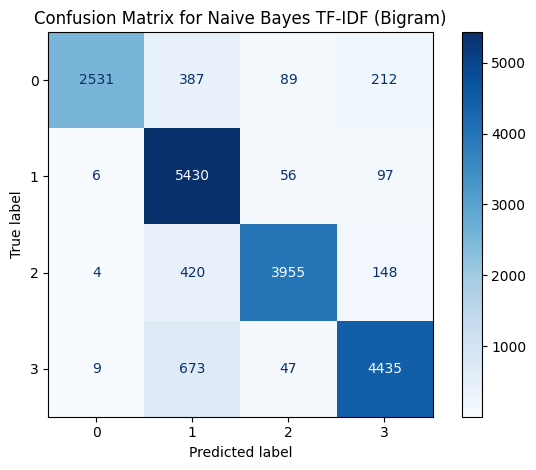

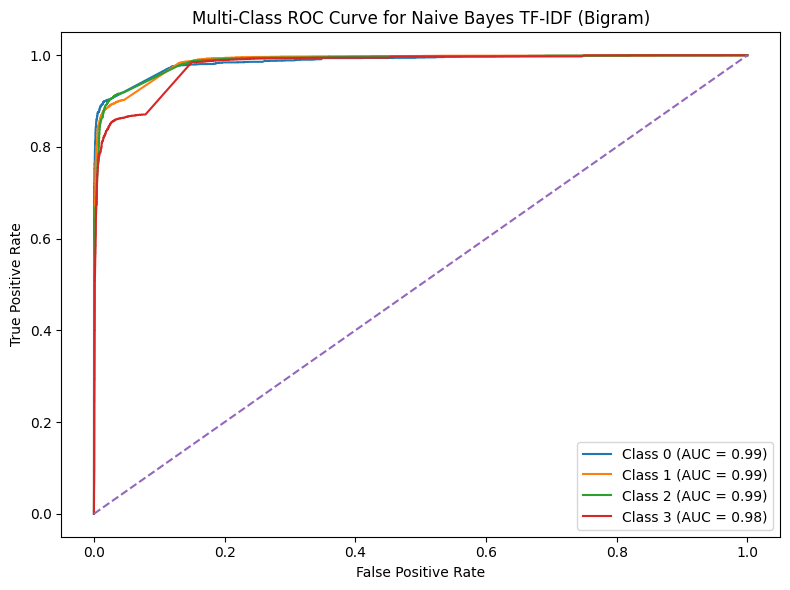

Sentence is:
This new feature is a game changer, I love using this new feature
Prediction by Naive Bayes TF-IDF (Bigram) is Positive
Sentence is:
This update is awful and ruined my workflow completely
Prediction by Naive Bayes TF-IDF (Bigram) is Negative


In [168]:
generate_evaluation(model=multinomialNB_tfidf_bigram, X_test=X_test, title="Naive Bayes TF-IDF (Bigram)")

# Result

In [169]:
result_df = result_df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)
result_df

,model name,accuracy,precision,recall,f1
0,Random Forest Count Vectorizer (Unigram),0.91,0.91,0.91,0.91
1,Random Forest TF-IDF (Unigram),0.91,0.92,0.91,0.91
2,Naive Bayes Count Vectorizer (Bigram),0.89,0.90,0.89,0.90
3,Naive Bayes TF-IDF (Bigram),0.88,0.90,0.88,0.88
4,Random Forest TF-IDF (Bigram),0.84,0.86,0.84,0.84
5,Random Forest Count Vectorizer (Bigram),0.84,0.86,0.84,0.85
6,Naive Bayes Count Vectorizer (Unigram),0.74,0.75,0.74,0.74
7,Random Forest Word2Vec,0.73,0.74,0.73,0.73
8,Naive Bayes TF-IDF (Unigram),0.72,0.76,0.72,0.71


## Model Performance Comparison

In [170]:
def labels(ax):
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v * 100:.2f}" for v in container.datavalues], padding=3)                   
    
def generate_performance_bar(df, title="Model Performance Comparison"):
    metrics = ['recall', 'precision', 'f1', 'accuracy']

    fig, axs = plt.subplots(4, 1, figsize=(14, 14))

    for i, metric in enumerate(metrics):
        df = df.sort_values(by=metric, ascending=False)
        ax = sns.barplot(x=metric, y="model name", hue="model name", legend=False, data=df, palette="Blues_d", ax=axs[i])
        ax.set_xlabel("")
        ax.set_title(metric.capitalize())
        labels(ax)
    plt.suptitle(title, y=1)        
    plt.tight_layout()
    plt.show()

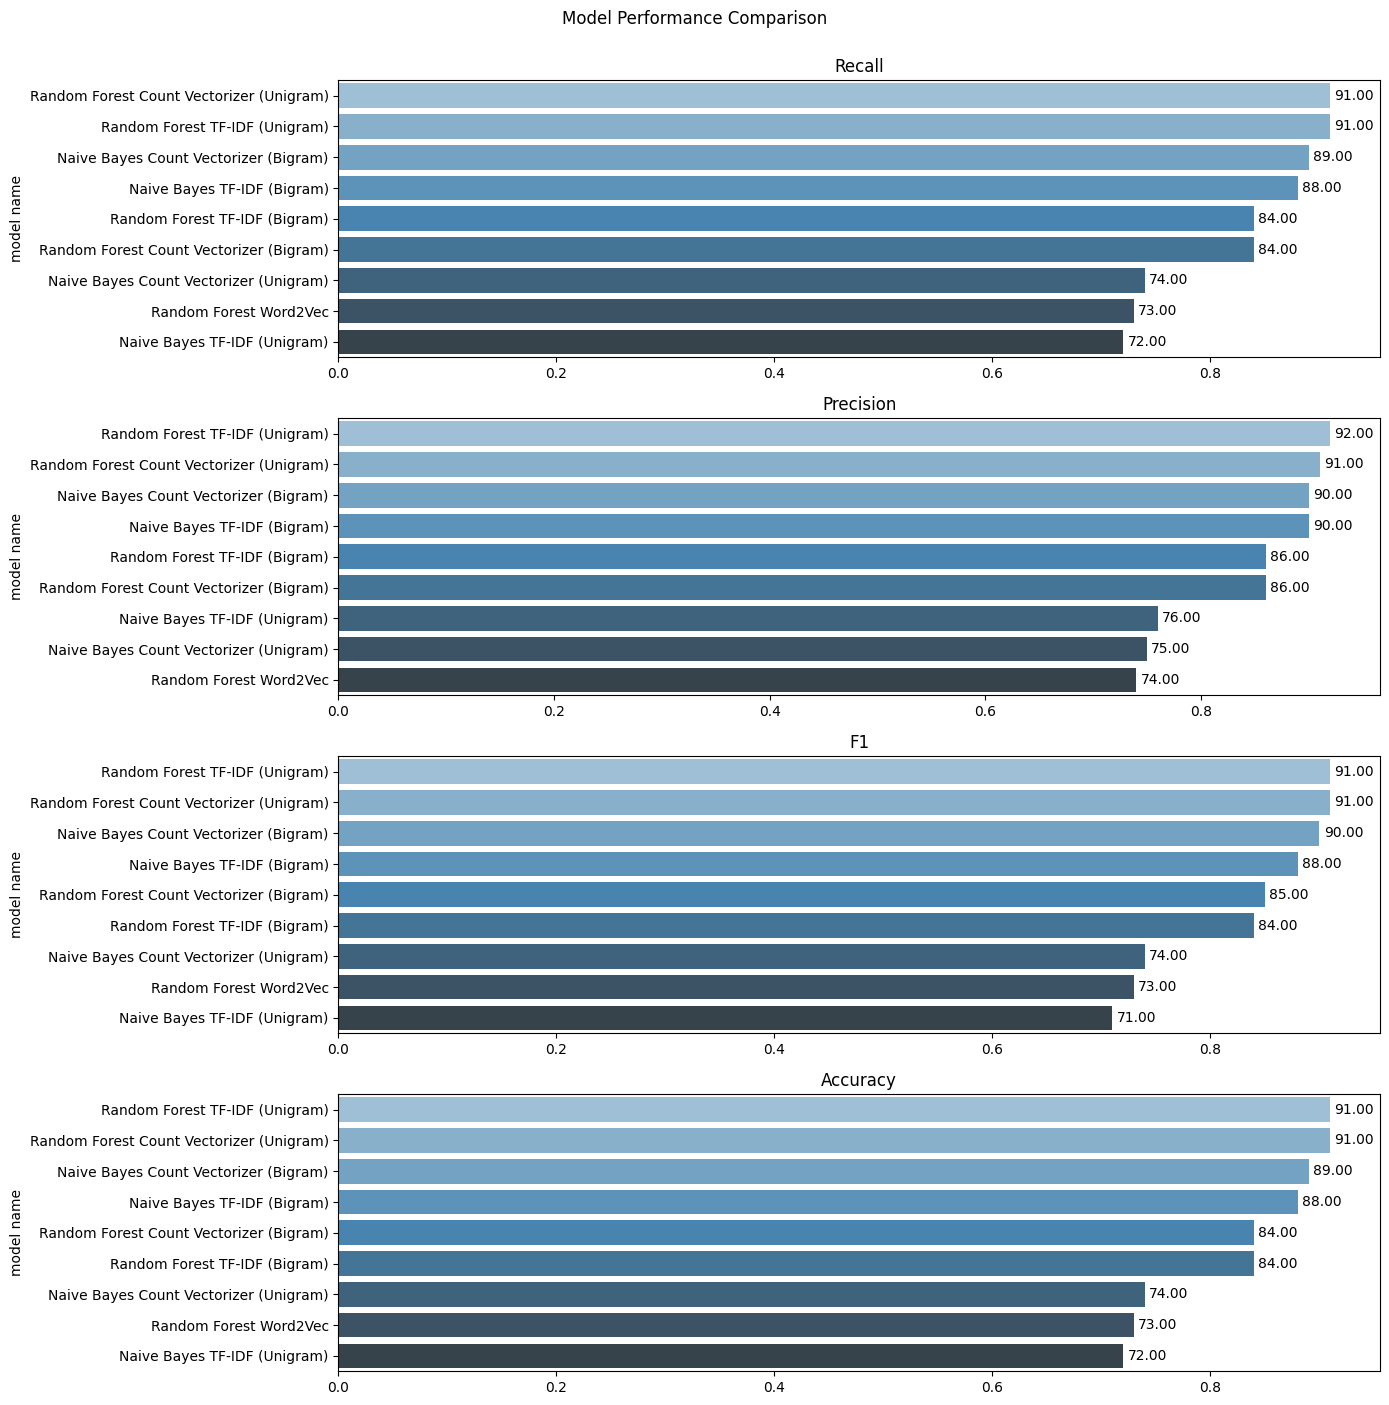

In [171]:
generate_performance_bar(result_df)